In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('DATA/cancer_classification.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

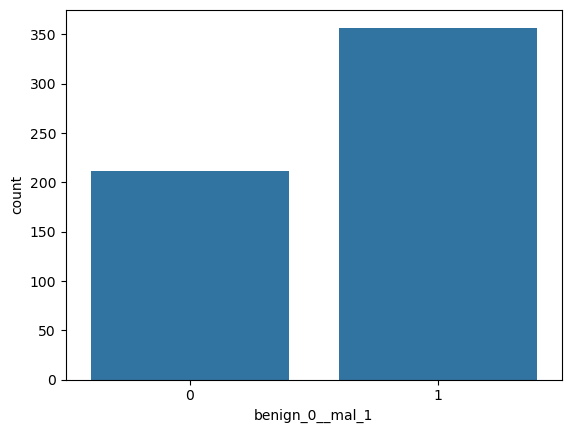

In [7]:
sns.countplot(x='benign_0__mal_1',data=df)

<Axes: >

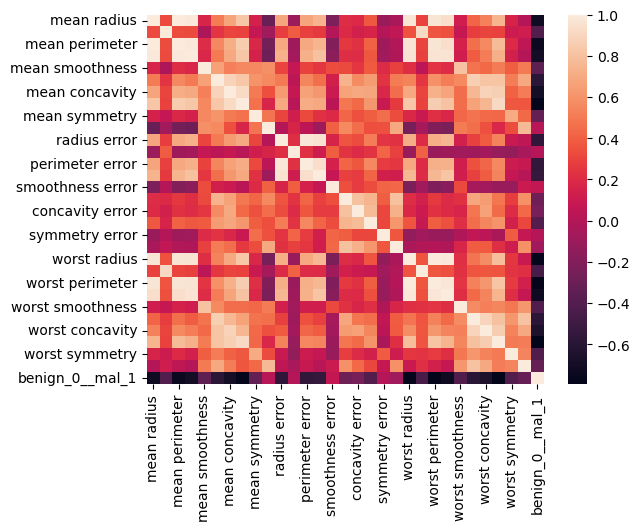

In [8]:
sns.heatmap(df.corr())

In [9]:
df.corr()['benign_0__mal_1'].sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

<Axes: >

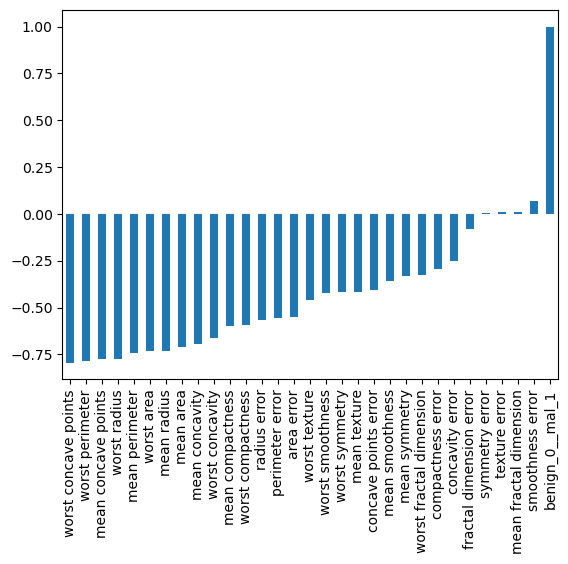

In [10]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

<Axes: >

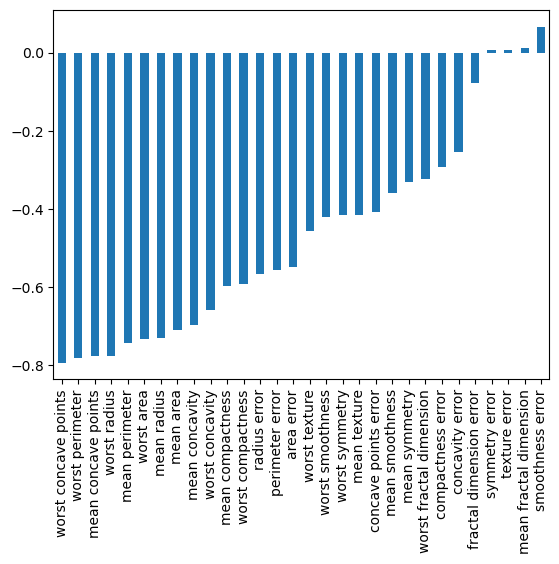

In [11]:
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind='bar')

## Train Test Split

In [12]:
X = df.drop('benign_0__mal_1',axis=1).values
y = df['benign_0__mal_1'].values

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=101)


## Scaling Data

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler = MinMaxScaler()

In [17]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [18]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout

In [20]:
X_train.shape

(426, 30)

In [21]:
model = Sequential()

# https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw

model.add(Dense(units=30,activation='relu'))

model.add(Dense(units=15,activation='relu'))


model.add(Dense(units=1,activation='sigmoid'))

# For a binary classification problem
model.compile(loss='binary_crossentropy', optimizer='adam')

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [22]:
# https://stats.stackexchange.com/questions/164876/tradeoff-batch-size-vs-number-of-iterations-to-train-a-neural-network
# https://datascience.stackexchange.com/questions/18414/are-there-any-rules-for-choosing-the-size-of-a-mini-batch

model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1
          )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6959 - val_loss: 0.6714
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6500 - val_loss: 0.6298
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6075 - val_loss: 0.5867
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5667 - val_loss: 0.5410
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5238 - val_loss: 0.5019
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4844 - val_loss: 0.4569
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4444 - val_loss: 0.4191
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4077 - val_loss: 0.3790
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3739 - val_loss: 0.3432
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3408 - val_loss: 0.3133
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3175 - val_loss: 0.2853
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - 

426/426 [==============================] - 0s 94us/sample - loss: 0.0399 - val_loss: 0.1443
Epoch 156/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0407 - val_loss: 0.1392
Epoch 157/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0396 - val_loss: 0.1438
Epoch 158/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0405 - val_loss: 0.1420
Epoch 159/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0415 - val_loss: 0.1415
Epoch 160/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0392 - val_loss: 0.1436
Epoch 161/600
426/426 [==============================] - 0s 93us/sample - loss: 0.0396 - val_loss: 0.1379
Epoch 162/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0402 - val_loss: 0.1473
Epoch 163/600
426/426 [==============================] - 0s 91us/sample - loss: 0.0414 - val_loss: 0.1449
Epoch 164/600
426/426 [==============================] - 0s 

426/426 [==============================] - 0s 94us/sample - loss: 0.0400 - val_loss: 0.1484
Epoch 233/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0350 - val_loss: 0.1521
Epoch 234/600
426/426 [==============================] - 0s 93us/sample - loss: 0.0369 - val_loss: 0.1465
Epoch 235/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0326 - val_loss: 0.1488
Epoch 236/600
426/426 [==============================] - 0s 95us/sample - loss: 0.0316 - val_loss: 0.1583
Epoch 237/600
426/426 [==============================] - 0s 93us/sample - loss: 0.0313 - val_loss: 0.1491
Epoch 238/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0325 - val_loss: 0.1653
Epoch 239/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0336 - val_loss: 0.1483
Epoch 240/600
426/426 [==============================] - 0s 92us/sample - loss: 0.0392 - val_loss: 0.1622
Epoch 241/600
426/426 [==============================] - 0s 

426/426 [==============================] - 0s 99us/sample - loss: 0.0409 - val_loss: 0.1652
Epoch 310/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0312 - val_loss: 0.1590
Epoch 311/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0291 - val_loss: 0.1667
Epoch 312/600
426/426 [==============================] - 0s 92us/sample - loss: 0.0268 - val_loss: 0.1658
Epoch 313/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0269 - val_loss: 0.1647
Epoch 314/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0267 - val_loss: 0.1750
Epoch 315/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0289 - val_loss: 0.1645
Epoch 316/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0263 - val_loss: 0.1651
Epoch 317/600
426/426 [==============================] - 0s 95us/sample - loss: 0.0271 - val_loss: 0.1685
Epoch 318/600
426/426 [==============================] - 0s 

426/426 [==============================] - 0s 96us/sample - loss: 0.0226 - val_loss: 0.1896
Epoch 387/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0264 - val_loss: 0.1810
Epoch 388/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0252 - val_loss: 0.1950
Epoch 389/600
426/426 [==============================] - 0s 97us/sample - loss: 0.0231 - val_loss: 0.1759
Epoch 390/600
426/426 [==============================] - 0s 101us/sample - loss: 0.0225 - val_loss: 0.1878
Epoch 391/600
426/426 [==============================] - 0s 100us/sample - loss: 0.0198 - val_loss: 0.1865
Epoch 392/600
426/426 [==============================] - 0s 95us/sample - loss: 0.0222 - val_loss: 0.1874
Epoch 393/600
426/426 [==============================] - 0s 97us/sample - loss: 0.0244 - val_loss: 0.2052
Epoch 394/600
426/426 [==============================] - 0s 101us/sample - loss: 0.0227 - val_loss: 0.1817
Epoch 395/600
426/426 [==============================] - 

426/426 [==============================] - 0s 95us/sample - loss: 0.0159 - val_loss: 0.2318
Epoch 464/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0158 - val_loss: 0.2159
Epoch 465/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0150 - val_loss: 0.2128
Epoch 466/600
426/426 [==============================] - 0s 101us/sample - loss: 0.0188 - val_loss: 0.2280
Epoch 467/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0148 - val_loss: 0.2164
Epoch 468/600
426/426 [==============================] - 0s 105us/sample - loss: 0.0178 - val_loss: 0.2127
Epoch 469/600
426/426 [==============================] - 0s 102us/sample - loss: 0.0177 - val_loss: 0.2232
Epoch 470/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0149 - val_loss: 0.2276
Epoch 471/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0147 - val_loss: 0.2184
Epoch 472/600
426/426 [==============================] - 

Epoch 540/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0126 - val_loss: 0.2521
Epoch 541/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0116 - val_loss: 0.2455
Epoch 542/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0132 - val_loss: 0.2970
Epoch 543/600
426/426 [==============================] - 0s 101us/sample - loss: 0.0172 - val_loss: 0.2415
Epoch 544/600
426/426 [==============================] - 0s 103us/sample - loss: 0.0183 - val_loss: 0.2610
Epoch 545/600
426/426 [==============================] - 0s 108us/sample - loss: 0.0125 - val_loss: 0.2543
Epoch 546/600
426/426 [==============================] - 0s 95us/sample - loss: 0.0163 - val_loss: 0.2473
Epoch 547/600
426/426 [==============================] - 0s 103us/sample - loss: 0.0139 - val_loss: 0.2642
Epoch 548/600
426/426 [==============================] - 0s 102us/sample - loss: 0.0134 - val_loss: 0.2489
Epoch 549/600
426/426 [==================

In [113]:
# model.history.history

In [114]:
model_loss = pd.DataFrame(model.history.history)

In [115]:
# model_loss

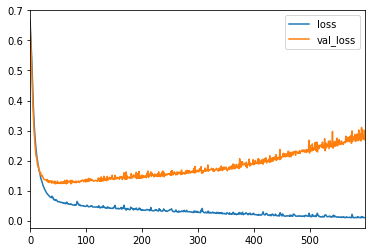

In [116]:
model_loss.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [117]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [119]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [121]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [122]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 0s 967us/sample - loss: 0.6927 - val_loss: 0.6778
Epoch 2/600
426/426 [==============================] - 0s 103us/sample - loss: 0.6653 - val_loss: 0.6505
Epoch 3/600
426/426 [==============================] - 0s 104us/sample - loss: 0.6330 - val_loss: 0.6182
Epoch 4/600
426/426 [==============================] - 0s 102us/sample - loss: 0.5982 - val_loss: 0.5789
Epoch 5/600
426/426 [==============================] - 0s 98us/sample - loss: 0.5523 - val_loss: 0.5269
Epoch 6/600
426/426 [==============================] - 0s 100us/sample - loss: 0.4953 - val_loss: 0.4664
Epoch 7/600
426/426 [==============================] - 0s 105us/sample - loss: 0.4343 - val_loss: 0.4037
Epoch 8/600
426/426 [==============================] - 0s 99us/sample - loss: 0.3751 - val_loss: 0.3478
Epoch 9/600
426/426 [==============================] - 0s 100us/sample - loss: 0.3233 - val_loss: 0.2980
Epoch 10/60

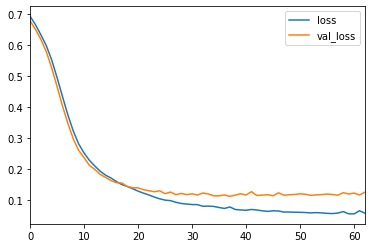

In [124]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## Example Three: Adding in DropOut Layers

In [125]:
from tensorflow.keras.layers import Dropout

In [126]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=15,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [127]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 0s 1ms/sample - loss: 0.6894 - val_loss: 0.6833
Epoch 2/600
426/426 [==============================] - 0s 101us/sample - loss: 0.6828 - val_loss: 0.6722
Epoch 3/600
426/426 [==============================] - 0s 103us/sample - loss: 0.6817 - val_loss: 0.6584
Epoch 4/600
426/426 [==============================] - 0s 99us/sample - loss: 0.6626 - val_loss: 0.6439
Epoch 5/600
426/426 [==============================] - 0s 97us/sample - loss: 0.6450 - val_loss: 0.6319
Epoch 6/600
426/426 [==============================] - 0s 101us/sample - loss: 0.6343 - val_loss: 0.6138
Epoch 7/600
426/426 [==============================] - 0s 108us/sample - loss: 0.6207 - val_loss: 0.5962
Epoch 8/600
426/426 [==============================] - 0s 103us/sample - loss: 0.6005 - val_loss: 0.5744
Epoch 9/600
426/426 [==============================] - 0s 103us/sample - loss: 0.5897 - val_loss: 0.5444
Epoch 10/600


426/426 [==============================] - 0s 98us/sample - loss: 0.1228 - val_loss: 0.1019
Epoch 79/600
426/426 [==============================] - 0s 103us/sample - loss: 0.1097 - val_loss: 0.0958
Epoch 80/600
426/426 [==============================] - 0s 104us/sample - loss: 0.1086 - val_loss: 0.0939
Epoch 81/600
426/426 [==============================] - 0s 102us/sample - loss: 0.1100 - val_loss: 0.0974
Epoch 82/600
426/426 [==============================] - 0s 107us/sample - loss: 0.1394 - val_loss: 0.0995
Epoch 83/600
426/426 [==============================] - 0s 110us/sample - loss: 0.1069 - val_loss: 0.0951
Epoch 84/600
426/426 [==============================] - 0s 108us/sample - loss: 0.1095 - val_loss: 0.0961
Epoch 85/600
426/426 [==============================] - 0s 108us/sample - loss: 0.1262 - val_loss: 0.0995
Epoch 86/600
426/426 [==============================] - 0s 105us/sample - loss: 0.1187 - val_loss: 0.1073
Epoch 87/600
426/426 [==============================] - 0s 9

<Axes: >

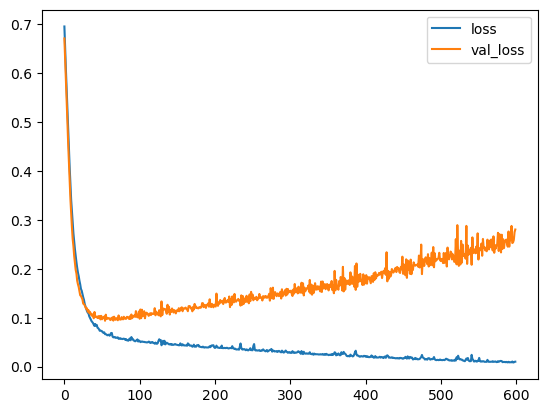

In [23]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

# Model Evaluation

In [25]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [26]:
from sklearn.metrics import classification_report,confusion_matrix

In [27]:
# https://en.wikipedia.org/wiki/Precision_and_recall
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        55
           1       0.99      0.93      0.96        88

    accuracy                           0.95       143
   macro avg       0.94      0.96      0.95       143
weighted avg       0.95      0.95      0.95       143



In [28]:
print(confusion_matrix(y_test,predictions))

[[54  1]
 [ 6 82]]
